<a href="https://colab.research.google.com/github/Avika-7/ML-Projects/blob/main/Project_1_SalesDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LOADING DATASET

In [ ]:
dataset = pd.read_excel('advertising_sales_data.xlsx')

PREPROCESSING DATA

In [ ]:
x = dataset.iloc[:, 1:4].values
y = dataset.iloc[:,-1].values

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(x[:,1:4])
x[:,1:4] = imputer.transform(x[:,1:4])

# **QUESTION 1.**

In [ ]:
#What is the average amount spent on TV advertising in the dataset?
avg_tv_spending = dataset['TV'].mean()
print("Average TV Spending:", avg_tv_spending)

Average TV Spending: 147.0425


# **QUESTION 2.**

In [ ]:
#What is the correlation between radio advertising expenditure and product sales?
correlation = dataset['Radio'].corr(dataset['Sales'])
print("Correlation between Radio and Sales:", correlation)

Correlation between Radio and Sales: 0.3497277129207837


*Conclusion: The Radio advertising and product sales are moderately correlated with the value 0.34, in the positive direction.*

# **QUESTION 3.**

In [ ]:
#To identify which advertising medium has the highest impact on sales based on the dataset, we'll find out the correlation of all methods of advertisment with sales.
tv_corr = dataset['TV'].corr(dataset['Sales'])
radio_corr = dataset['Radio'].corr(dataset['Sales'])
newspaper_corr = dataset['Newspaper'].corr(dataset['Sales'])

print("Correlation with TV:", tv_corr)
print("Correlation with Radio:", radio_corr)
print("Correlation with Newspaper:", newspaper_corr)

Correlation with TV: 0.9012079133023306
Correlation with Radio: 0.3497277129207837
Correlation with Newspaper: 0.15796002615492621


*Conclusion : Sales show a strong positive correlation with TV advertising, with a correlation coefficient of 0.90, indicating that increased TV ad spending is closely associated with higher sales. Radio advertising has the second strongest impact, followed by Newspaper advertising, which shows a comparatively weaker relationship with sales with values 0.34 and 0.15 respectively.*

#**QUESTION 4.**

In [ ]:
# Plot a linear regression line that includes all variables (TV, Radio, Newspaper) to predict Sales, and visualize the model's predictions against the actual sales values.

# Splitting the data into training and testing sets
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

#Training the model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)

LinearRegression()

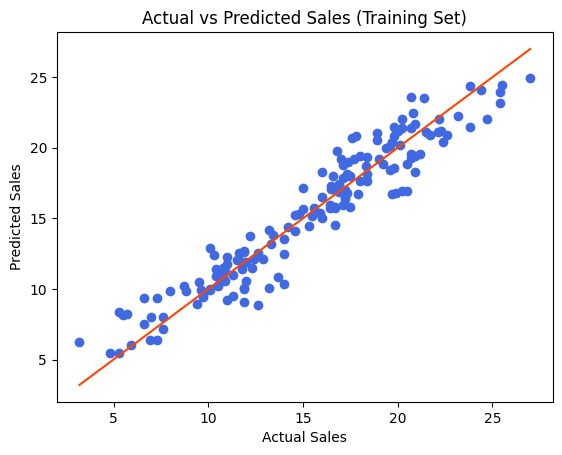

In [ ]:
y_pred = regressor.predict(x_test)

#PLOTTING TRAINING SET
plt.scatter(y_train, regressor.predict(x_train), color='royalblue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='orangered')
plt.title('Actual vs Predicted Sales (Training Set)')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

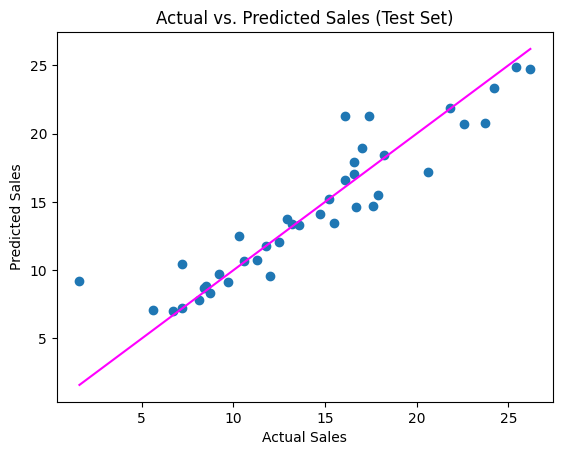

In [ ]:
#PLOTTING TEST SET
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='magenta')
plt.title('Actual vs. Predicted Sales (Test Set)')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

# **QUESTION 5.**

In [ ]:
# How would sales be predicted for a new set of advertising expenditures: $200 on TV, $40 on Radio, and $50 on Newspaper?
print(regressor.predict([[200,40,50]]))

[19.79515412]


# **QUESTION 6.**

In [ ]:
#How does the performance of the linear regression model change when the dataset is normalized?

#Normalisation of data in range 0-1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

#LINEAR REGRESSOR MODEL AFTER NORMALISATION
from sklearn.model_selection import train_test_split
x_scaled_train,x_scaled_test,y_train_scaled,y_test_scaled = train_test_split(x_scaled,y,test_size=0.2,random_state=0)

from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_scaled_train, y_train_scaled)

y_pred_scaled = regressor.predict(x_scaled_test)

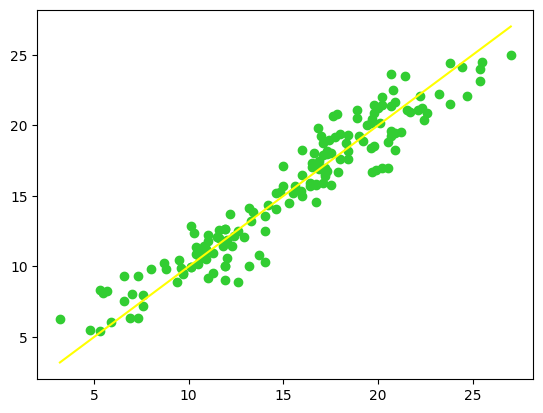

In [ ]:
#PLOTTING TRAIN SET
plt.scatter(y_train_scaled, regressor.predict(x_scaled_train), color='limegreen')
plt.plot([y_train_scaled.min(), y_train_scaled.max()], [y_train_scaled.min(), y_train_scaled.max()], color='yellow')

Text(0, 0.5, 'Predicted Sales')

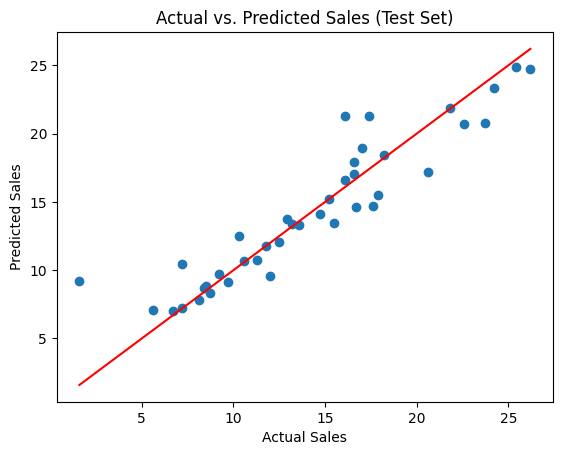

In [ ]:
#PLOTTING TEST SET
plt.scatter(y_test_scaled, y_pred_scaled)
plt.plot([y_test_scaled.min(), y_test_scaled.max()], [y_test_scaled.min(), y_test_scaled.max()], color='red')
plt.title('Actual vs. Predicted Sales (Test Set)')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

*Conclusion : As we see, the performance of the Linear Regression model does not change when the data is normalised. This is because skicit-learn's LinearRegression uses analytical solution and not gradient based so it handles the feature scales well. *